### **CELL 1: IMPORTS AND SETUP**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
import os

notebook_dir = os.getcwd()
if "analysis" in notebook_dir:
    base_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
else:
    base_dir = os.path.abspath(notebook_dir)

db_path = os.path.join(
    base_dir, "database", "sales.db").replace("\\", "/")
engine = create_engine(f"sqlite:///{db_path}")

def read_sql_file(filepath):
    if "analysis" in os.getcwd():
        full_path = os.path.abspath(
            os.path.join(os.getcwd(), "..", filepath))
    else:
        full_path = os.path.abspath(filepath)
    with open(full_path, "r") as f:
        return f.read()

def save_and_show(filename):
    os.makedirs(os.path.join(base_dir, "analysis", "charts"),
                exist_ok=True)
    plt.savefig(
        os.path.join(base_dir, "analysis", "charts", filename),
        dpi=150, bbox_inches="tight")
    plt.show()

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

df = pd.read_sql("SELECT * FROM sales_clean", engine)

print("Setup complete")
print(f"Total rows in database: {len(df):,}")

Setup complete
Total rows in database: 1,234


### **CELL 2: KPI SUMMARY**

In [3]:
total_revenue = df["revenue"].sum()
total_orders = df["order_id"].nunique()
total_lost = df["lost_revenue"].sum()
total_days = int(df["day_number"].max())
top_city = (df[df["city"] != "Unknown"].groupby("city")["revenue"].sum().idxmax())
top_product = (df.groupby("product_name")["revenue"].sum().idxmax())
most_lost = (df.groupby("product_name")["lost_revenue"].sum().idxmax())

print("E-COMMERCE PIPELINE - 30 DAY KPI SUMMARY")
print(f"Days of data            : {total_days}")
print(f"Total orders            : {total_orders:,}")
print(f"Total revenue earned    : Rs.{total_revenue:,.0f}")
print(f"Total revenue lost      : Rs.{total_lost:,.0f}")
print(f"Loss rate               : "f"{total_lost / (total_revenue + total_lost) * 100:.1f}%")
print(f"Top city                : {top_city}")
print(f"Top product (revenue)   : {top_product}")
print(f"Highest loss            : {most_lost}")


E-COMMERCE PIPELINE - 30 DAY KPI SUMMARY
Days of data            : 30
Total orders            : 1,207
Total revenue earned    : Rs.5,127,676
Total revenue lost      : Rs.1,586,704
Loss rate               : 23.6%
Top city                : Hyderabad
Top product (revenue)   : Power Bank
Highest loss            : Wireless Earbuds


### **CELL 3: ETL DATA QUALITY REPORT**

In [4]:
total_rows = len(df)

unknown_names = len(df[df["customer_name"] == "Unknown"])
unknown_phones = len(df[df["customer_phone"] == "Unknown"])
unknown_cities = len(df[df["city"] == "Unknown"])

invalid_phones = len(df[df["phone_valid"] == 0])

print("ETL PIPELINE - DATA QUALITY REPORT")
print(f"\nTotal rows processed: {total_rows:,}")
print()
print(f"Missing customer names: {unknown_names}"f" ({unknown_names / total_rows * 100:.1f}%)")
print(f"Missing phone numbers : {unknown_phones}"f" ({unknown_phones / total_rows * 100:.1f}%)")
print(f"Missing city values   : {unknown_cities}"f" ({unknown_cities / total_rows * 100:.1f}%)")
print(f"Invalid phone numbers : {invalid_phones}"f" ({invalid_phones / total_rows * 100:.1f}%)")

print()
print("How each issue was handled:\n")
print("Missing values   : filled with 'Unknown'")
print("Wrong casing     : fixed with .str.title()")
print("Phone formatting : cleaned with .str.replace()")
print("Duplicate orders : removed with drop_duplicates()")
print("Invalid phones   : flagged in phone_valid column")

ETL PIPELINE - DATA QUALITY REPORT

Total rows processed: 1,234

Missing customer names: 111 (9.0%)
Missing phone numbers : 92 (7.5%)
Missing city values   : 104 (8.4%)
Invalid phone numbers : 181 (14.7%)

How each issue was handled:

Missing values   : filled with 'Unknown'
Wrong casing     : fixed with .str.title()
Phone formatting : cleaned with .str.replace()
Duplicate orders : removed with drop_duplicates()
Invalid phones   : flagged in phone_valid column


### **CELL 4: PAYMENT METHOD BREAKDOWN**

Payment Method Breakdown:

 payment_method    total_orders   total_revenue  order_share_pct
            UPI             508       2,049,308            41.17
           Card             344       1,562,888            27.88
            COD             192         814,779            15.56
    Net Banking             140         484,241            11.35
         Wallet              50         216,460             4.05



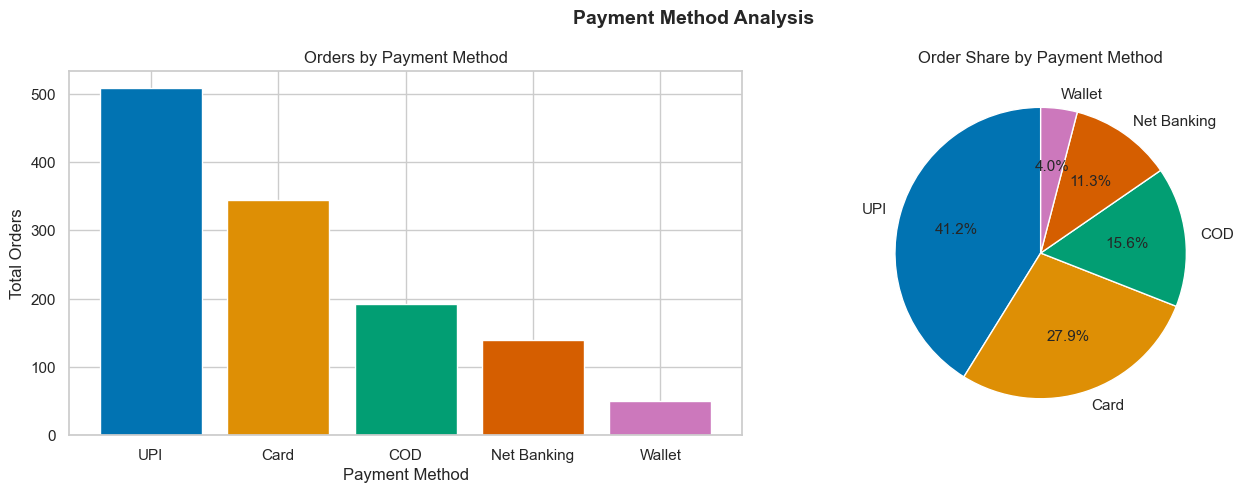

In [5]:
payment = pd.read_sql("""
                      SELECT 
                      payment_method,
                      COUNT(order_id) AS total_orders,
                      SUM(revenue) AS total_revenue,
                      ROUND(COUNT(order_id) * 100.0/
                      SUM(COUNT(order_id)) OVER (), 2) AS order_share_pct
                      FROM sales_clean
                      GROUP BY payment_method
                      ORDER BY total_orders DESC
                      """, engine)

payment["total_revenue"] = payment["total_revenue"].apply(lambda x: f"{x:,.0f}")

print("Payment Method Breakdown:\n")
print(payment.to_string(index=False, col_space = 15))
print()

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

my_colors = sns.color_palette("colorblind", 5)

#Left - bar chart
axes[0].bar(
    payment["payment_method"],
    payment["total_orders"],
    color = my_colors
)
axes[0].set_title("Orders by Payment Method")
axes[0].set_xlabel("Payment Method")
axes[0].set_ylabel("Total Orders")

#Right - pie chart
axes[1].pie(
    payment["order_share_pct"],
    labels = payment["payment_method"],
    autopct = "%1.1f%%",
    colors = my_colors,
    startangle = 90
)
axes[1].set_title("Order Share by Payment Method")

plt.suptitle("Payment Method Analysis", fontsize = 14, fontweight = "bold")
plt.tight_layout()
save_and_show("payment_methods.png")

**Insight:** Unsurprisingly, UPI dominates at 41% of all transactions, which makes perfect sense for the Indian market right now. It's closely followed by Card transactions which takes up 28%. While Cash on Delivery is still an option people use, the data shows our audience has overwhelmingly shifted to digital-first payments.

### **CELL 5: REVENUE CAPTURE RATE**

Revenue Capture Rate by Product:

        product_name       earned         lost    potential  capture_rate_pct
    Wireless Earbuds      582,735      853,212    1,435,947              40.6
     Creatine Powder      165,416      147,436      312,852              52.9
          Face Serum      117,214       78,522      195,736              59.9
            Gym Ball      193,380      116,907      310,287              62.3
           Skin Tint      261,382      137,885      399,267              65.5
    Sunscreen SPF 50      125,216       51,428      176,644              70.9
   Fish Oil Capsules      155,277       51,120      206,397              75.2
          Gym Gloves      123,012       36,720      159,732              77.0
    Whey Protein Bar       72,059       21,229       93,288              77.2
       Green Tea box      109,242       29,376      138,618              78.8
           Jump Rope       93,183       15,007      108,190              86.1
Multivitamin Tablets      218,

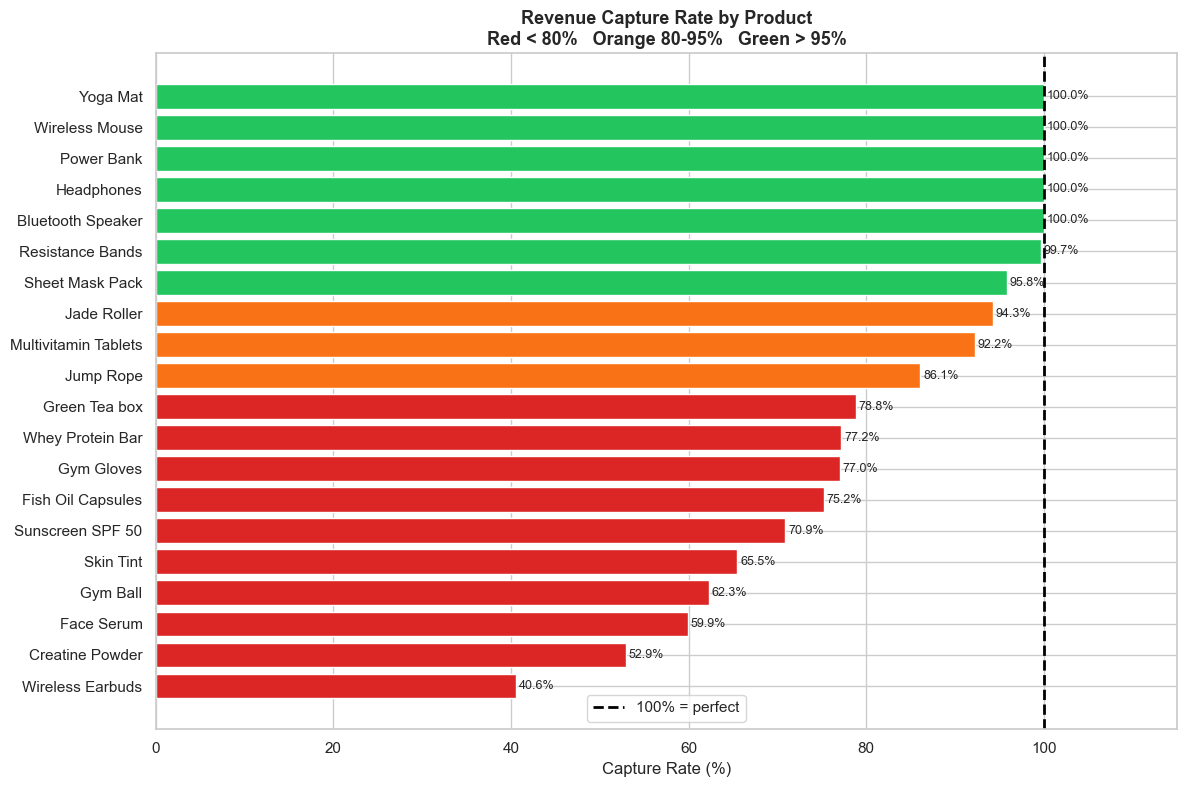

In [6]:
#QUESTION: How much of our potential revenue are we capturing?

#Potential = earned + lost
#Capture rate = earned / potential x 100

capture = pd.read_sql("""
                      SELECT
                      product_name,
                      SUM(revenue) AS earned,
                      SUM(lost_revenue) AS lost,
                      SUM(revenue) + SUM(lost_revenue) AS potential,
                      ROUND(SUM(revenue) * 100.0 / NULLIF(SUM(revenue) + SUM(lost_revenue), 0), 1) AS capture_rate_pct
                      FROM sales_clean
                      GROUP BY product_name
                      ORDER BY capture_rate_pct ASC
                      """, engine)

capture["earned"] = capture["earned"].apply(lambda x: f"{x:,.0f}")
capture["lost"] = capture["lost"].apply(lambda x: f"{x:,.0f}")
capture["potential"] = capture["potential"].apply(lambda x: f"{x:,.0f}")

print("Revenue Capture Rate by Product:\n")
print(capture.to_string(index = False, col_space = 12))
print()
print(f"Worst: {capture.iloc[0]['product_name']} "
      f"at {capture.iloc[0]['capture_rate_pct']}% capture rate")
print(f"Best : {capture.iloc[-1]['product_name']} "
      f"at {capture.iloc[-1]['capture_rate_pct']}% capture rate")


colors = ["#DC2626" if x < 80 else
          "#F97316" if x < 95 else
          "#22C55E"
          for x in capture["capture_rate_pct"]]

fig, ax = plt.subplots(figsize = (12, 8))
bars = ax.barh(
    capture["product_name"],
    capture["capture_rate_pct"],
    color = colors, edgecolor = "white")

ax.axvline(x = 100, color = "black", linestyle = "--",
           linewidth = 2, label = "100% = perfect")

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
            f"{w:.1f}%", va = "center", fontsize = 9)

ax.set_title(
    "Revenue Capture Rate by Product\n"
    "Red < 80%   Orange 80-95%   Green > 95%",
    fontsize = 13, fontweight = "bold")
ax.set_xlabel("Capture Rate (%)")
ax.set_xlim(0, 115)
ax.legend()
plt.tight_layout()
save_and_show("q1_capture_rate.png")

**Insight:** The capture rate exposes the exact gap between actual sales and true market demand. Wireless Earbuds suffered a catastrophic stockout, capturing only 40.6% of its potential revenue (earning Rs. 5.82 Lakhs but losing Rs. 8.53 Lakhs). Had the warehouse been adequately prepared for the viral spike, this single product could have generated over Rs. 14.3 Lakhs in revenue. Conversely, items at 100% (like the Yoga Mat) successfully captured all potential revenue with zero stockouts. This metric proves that evaluating a business solely on "revenue earned" completely hides the massive potential revenue being left on the table.

### **CELL 6: STOCKOUT SPREAD TIMELINE**

Stockout Timeline:

        product_name    stockout_day   stockout_date      total_lost
    Wireless Earbuds               9      2024-03-09         853,212
     Creatine Powder              16      2024-03-16         147,436
          Face Serum              18      2024-03-18          78,522
            Gym Ball              19      2024-03-19         116,907
    Sunscreen SPF 50              20      2024-03-20          51,428
           Skin Tint              21      2024-03-21         137,885
    Whey Protein Bar              21      2024-03-21          21,229
       Green Tea box              23      2024-03-23          29,376
          Gym Gloves              23      2024-03-23          36,720
   Fish Oil Capsules              24      2024-03-24          51,120
           Jump Rope              26      2024-03-26          15,007
         Jade Roller              28      2024-03-28          21,402
     Sheet Mask Pack              28      2024-03-28           7,527
Multivitamin T

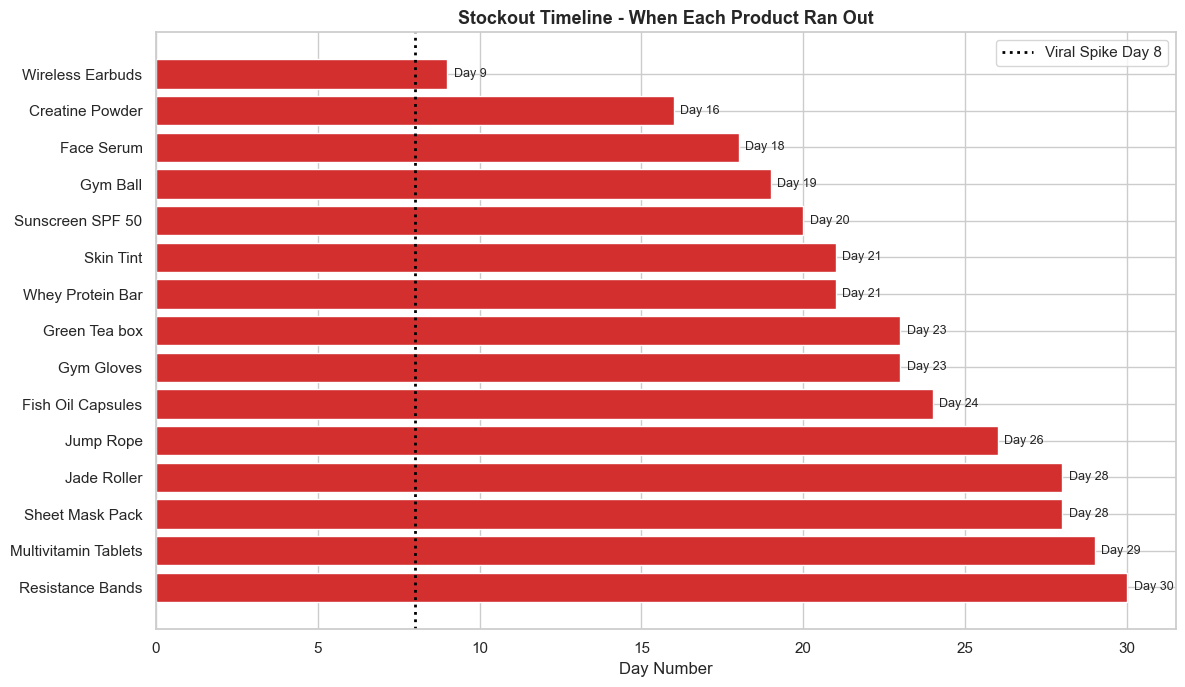

In [7]:
#QUESTION: How quickly did stockouts spread after Day 8?

stockout_timeline = pd.read_sql("""
                                SELECT
                                product_name,
                                MIN(CASE WHEN stock_remaining = 0
                                THEN day_number END) AS stockout_day,
                                MIN(CASE WHEN stock_remaining = 0
                                THEN date END) as stockout_date,
                                SUM(lost_revenue) AS total_lost
                                FROM sales_clean
                                GROUP BY product_name
                                HAVING stockout_day IS NOT NULL
                                ORDER BY stockout_day ASC
                                """, engine)

stockout_timeline["total_lost"] = stockout_timeline["total_lost"].apply(lambda x: f"{x:,.0f}")

print("Stockout Timeline:\n")
print(stockout_timeline.to_string(index=False, col_space = 15))
print()

first = int(stockout_timeline["stockout_day"].min())
last  = int(stockout_timeline["stockout_day"].max())
print(f"First stockout : Day {first}")
print(f"Last stockout  : Day {last}")
print(f"Spread over    : {last - first} days")
print(f"Products lost  : {len(stockout_timeline)}")

fig, ax = plt.subplots(figsize = (12, 7))

ax.barh(
    stockout_timeline["product_name"][::-1],
    stockout_timeline["stockout_day"][::-1],
    color = "#D32F2F", edgecolor = "white")

ax.axvline(x = 8, color = "black", linestyle = ":",
           linewidth = 2, label = "Viral Spike Day 8")

for i, (_, row) in enumerate(
        stockout_timeline[::-1].iterrows()):
    ax.text(row["stockout_day"] + 0.2, i,
            f"Day {int(row['stockout_day'])}",
            va = "center", fontsize = 9)

ax.set_title(
    "Stockout Timeline - When Each Product Ran Out",
    fontsize = 13, fontweight = "bold")
ax.set_xlabel("Day Number")
ax.legend()
plt.tight_layout()
save_and_show("q2_stockout_timeline.png")

**Insight:** The Day 8 viral spike triggered a cascade. Wireless Earbuds stocked out on Day 9, just 1 day after the spike. But the damage spread over the following 21 days as other products gradually ran dry. This spread shows the business had multiple windows to intervene. The automated pipeline's WARNING alerts on Day 15 for Creatine Powder (2 units remaining) gave exactly that window, but without a system to act on the alert, losses continued accumulating.

### **CELL 7: CITY IMPACT ANALYSIS**

City Impact Analysis:

      city     earned       lost  lost_rate_pct
 Hyderabad  1,675,201    436,828           20.0
 Bengaluru  1,361,559    397,783           22.0
    Mumbai    609,703    202,229           24.0
   Kolkata    392,569    179,713           31.0
    Punjab    336,404     57,526           14.0
   Chennai    373,335     54,620           12.0


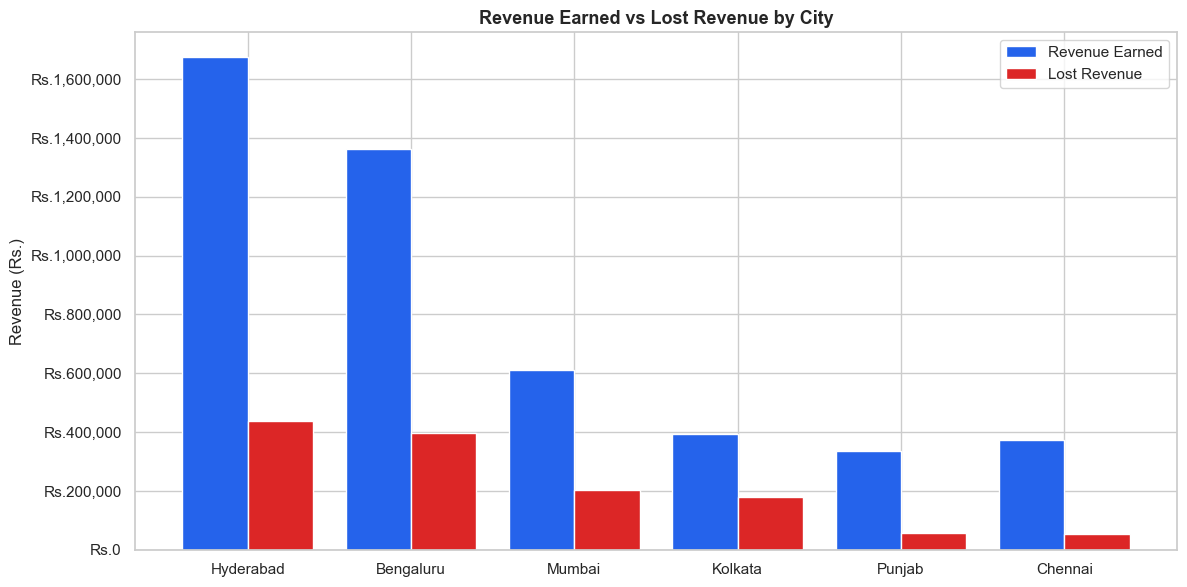

In [8]:
#QUESTION: Which cities are most underserved by stockouts?

city_impact  = pd.read_sql("""
                           SELECT
                           city,
                           SUM(revenue) as earned,
                           SUM(lost_revenue) AS lost,
                           ROUND(SUM(lost_revenue) * 100 / NULLIF(SUM(revenue) + SUM(lost_revenue), 0), 1) AS lost_rate_pct
                           FROM sales_clean
                           WHERE city != "Unknown"
                           GROUP BY city
                           ORDER BY lost DESC
                           """, engine)

print_format = {
    'earned': lambda x: f"{x:,.0f}",
    'lost': lambda x: f"{x:,.0f}"
}

print("City Impact Analysis:\n")
print(city_impact.to_string(index = False, col_space = 10, formatters=print_format))

x = range(len(city_impact))
width = 0.4

fig, ax = plt.subplots(figsize = (12, 6))
ax.bar([i - width/2 for i in x],
       city_impact["earned"],
       width = width, label = "Revenue Earned",
       color = "#2563EB")
ax.bar([i + width/2 for i in x],
       city_impact["lost"],
       width = width, label = "Lost Revenue",
       color = "#DC2626")

ax.set_xticks(list(x))
ax.set_xticklabels(city_impact["city"])
ax.set_title("Revenue Earned vs Lost Revenue by City",
             fontsize = 13, fontweight = "bold")
ax.set_ylabel("Revenue (Rs.)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"Rs.{x:,.0f}"))
ax.legend()
plt.tight_layout()
save_and_show("q3_city_impact.png")

**Insight:** Hyderabad and Bengaluru have the highest absolute lost revenue - Rs.436,828 and Rs.397,783 respectively. These are the cities where restocking matters most in terms of raw rupee recovery. But Kolkata has the highest loss rate at 31%. Despite being a smaller market, customers there are being underserved at the highest rate. Restocking strategy should prioritise two things: fix absolute losses in Hyderabad and Bengaluru first, then address the disproportionate loss rate in Kolkata before it damages customer retention in that market.

### **CELL 8: REORDER RECOMMENDATIONS**

In [9]:
#QUESTION: What should the business do now?

#Recommended stock = total demand x 1.2 (20% safety buffer)

recommendations = pd.read_sql("""
                              SELECT 
                              product_name AS product,
                              SUM(quantity) AS demand,
                              SUM(fulfilled) AS sold,
                              SUM(lost_sales) AS lost,
                              ROUND(SUM(quantity) / 30.0, 1) AS avg_daily_demand,
                              ROUND((SUM(quantity) / 30.0) * 2, 0) AS reorder_pt,
                              ROUND(SUM(quantity) * 1.2, 0) AS rec_stock_30d
                              FROM sales_clean
                              GROUP BY product_name
                              ORDER BY lost DESC
                              """, engine)

print("Reorder Recommendations for Next 30-Day Period:\n")
print(recommendations.to_string(index=False))

affected = recommendations[recommendations["lost"] > 0]

print()
print("=" * 55)
print("  TOP 5 PRIORITY RESTOCKS")
print("=" * 55)
for _, row in affected.head(5).iterrows():
    print(f"{row['product']}")
    print(f"Avg daily demand   : {row['avg_daily_demand']} units")
    print(f"Min reorder point  : {int(row['reorder_pt'])} units")
    print(f"Recommended stock  : {int(row['rec_stock_30d'])} units")
    print()

Reorder Recommendations for Next 30-Day Period:

             product  demand  sold  lost  avg_daily_demand  reorder_pt  rec_stock_30d
    Wireless Earbuds     653   265   388              21.8        44.0          784.0
     Creatine Powder     348   184   164              11.6        23.0          418.0
          Face Serum     344   206   138              11.5        23.0          413.0
            Gym Ball     353   220   133              11.8        24.0          424.0
           Skin Tint     333   218   115              11.1        22.0          400.0
    Sunscreen SPF 50     316   224    92              10.5        21.0          379.0
          Gym Gloves     348   268    80              11.6        23.0          418.0
   Fish Oil Capsules     323   243    80              10.8        22.0          388.0
    Whey Protein Bar     312   241    71              10.4        21.0          374.0
       Green Tea box     302   238    64              10.1        20.0          362.0
     

**Insight:** Wireless Earbuds are in a category of their own. Driven by the Day 8 viral spike they demand an average of 21.8 units per day. To prevent another stockout the recommended starting stock is 784 units which is nearly 2.5 times the original stock of 310 units we started with. Even without a viral event normal demand requires a constant buffer of at least 44 units.

The remaining 14 products that ran out of stock show a very consistent pattern. They average about 10 to 12 units of daily demand and require a minimum reorder point of 21 to 24 units. Stocking these items between 370 and 430 units will safely cover a full 30 day period with a 20 percent safety buffer built in.

The five products that never stocked out like the Yoga Mat and Wireless Mouse already had enough initial inventory to handle their demand. The math confirms their current stock levels are perfectly fine so no changes are needed for that group.

The final business recommendation is simple. The warehouse should use the recommended 30 day stock numbers as their exact order quantity for next month. Furthermore they need to set an automated system trigger at the minimum reorder point. This ensures the data pipeline warns the team before the shelves go empty instead of just reporting on the financial losses after the fact.

### **CELL 9: IMPORT DATAFRAME AS CSV**

In [15]:
import os

df.to_csv("../data/final_sales_data.csv", index = False)
print("File saved successfully!")

File saved successfully!
